import libraries

In [137]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

import dataset

In [138]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Now Data Devided into Two categories

In [139]:
x = df.drop(columns=['math_score'])
y = df['math_score']
x
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

now we check numerical or categorical variable

In [140]:
num_fecture = x.select_dtypes(exclude='object').columns
cat_fecture = x.select_dtypes(include='object').columns

cat_fecture

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')

now we will split the dataset

In [141]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [142]:
column = ColumnTransformer(
    [
        ("scalar",StandardScaler(),num_fecture),
        ("one",OneHotEncoder(),cat_fecture)
    ]
)

x_train = column.fit_transform(x_train)
x_test = column.transform(x_test)
x_train

array([[ 0.03079054,  0.43405338,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 0.9302895 ,  0.96470125,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 1.34544287,  1.1636942 ,  1.        , ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.52274728, -1.02522827,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [-1.49143847, -1.02522827,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 1.48382733,  1.36268716,  1.        , ...,  1.        ,
         0.        ,  1.        ]])

Create an Evaluate function to give all matrics after model training

In [143]:
from sklearn.linear_model import LogisticRegression,LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

now we will create a function


In [144]:
def evaluate_model(true,predicted):
    r2_square = r2_score(true,predicted)
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    return mae, rmse, r2_square




In [145]:
models = {
    "LinearRegression" : LinearRegression(),
    "Ridge" : Ridge(),
    "Lasso" : Lasso(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(),
    "KNeighborsRegressor" : KNeighborsRegressor()
}
model_list = []
r2_list =[]

In [146]:
for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(x_train,y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')




LinearRegression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5925
- Mean Absolute Error: 5.2053
- R2 Score: 0.8072
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5173
- Mean Absolute Error: 5.1557
- R2 Score: 0.8254


DecisionTreeRegressor
Model performance for Training set
- Root Mean Squared Error: 0.2795
- Mean Absolute Error: 0.0187
- R2 Score: 0.9997
------------------------

plot y_test_pred and y_test

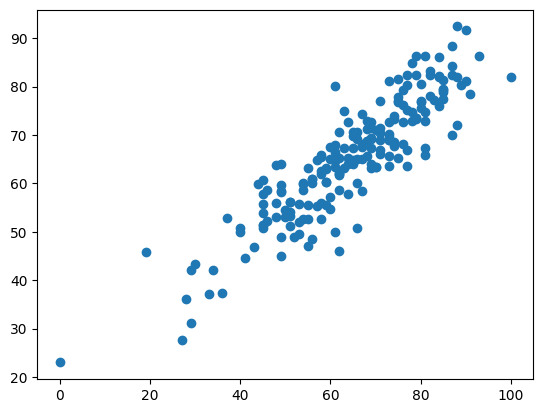

In [147]:
plt.scatter(y_test,y_test_pred)
plt.show()

create a best fit line along with a marginal plan

<Axes: xlabel='math_score'>

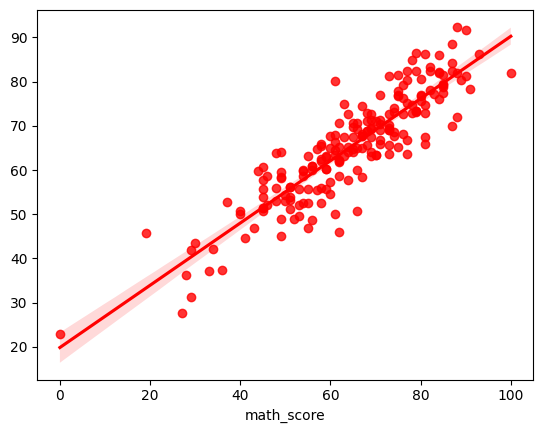

In [148]:
sns.regplot(x = y_test,y = y_test_pred,color='red')